<img src="https://www.mmu.edu.my/fci/wp-content/uploads/2021/01/FCI_wNEW_MMU_LOGO.png" style="height: 80px;" align=right>


CDS6314 DATA MINING

Trimester 1, 2024/2025

Project (30%)

NAME : LAM ZI FOONG  
ID : 1221303175

NAME : SURENTHIRAN A/L SHAMOSAMUGAM NATHAN  
ID : 1211104053

NAME : CHAI DI SHENG  
ID : 1211101961

NAME : MUHAMMAD ZHARIF BIN MOHD FAIZAL  
ID : 1171100428

# Google Colab only

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
d_path = ('/content/drive/MyDrive/Data_Mining_G7/')

# DATA MINING TASK:

The main task in this project is to perform a prediction on the future trends of death rates.
This task was motivated by the need to understand the number of deaths. This is important
so that public health planning and allocating resources can be done. The dataset must be
clean by ensuring that no missing value and ensure consistency in formatting. Conduct a
comprehensive exploration of the dataset to gain insights into the distribution of death rates
across different countries, trends over time, and the impact of various risk factors. By using
visualise data graphs to find any common patterns. Analyse the predicted trends to identify
emerging patterns, potential areas of concern, and opportunities for intervention and
policy-making in public health.

# Data Preprocessing

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


try:
  d_path
except NameError:
  d_path = ''

data = pd.read_csv(d_path+'Dataset_Group07.csv')

info_dict = {
    'Column': data.columns,
    'Non-Null Count': data.notnull().sum().values,
    'Dtype': data.dtypes.values
}

info_df = pd.DataFrame(info_dict)
info_df.index.name = '#'
info_df.style.set_table_styles([dict(selector='th', props=[('text-align', 'center')])])

,Column,Non-Null Count,Dtype
#,,,
0,Country/Territory,6120,object
1,Code,6120,object
2,Year,6120,int64
3,Meningitis,6120,int64
4,Alzheimer's Disease and Other Dementias,6120,int64
5,Parkinson's Disease,6120,int64
6,Nutritional Deficiencies,6120,int64
7,Malaria,6120,int64
8,Drowning,6120,int64


## Data Cleaning

In [5]:
# Check for missing data
missing_values = data.isnull().sum()
print("\nMissing Values\n")
print(missing_values)


Missing Values

Country/Territory                             0
Code                                          0
Year                                          0
Meningitis                                    0
Alzheimer's Disease and Other Dementias       0
Parkinson's Disease                           0
Nutritional Deficiencies                      0
Malaria                                       0
Drowning                                      0
Interpersonal Violence                        0
Maternal Disorders                            0
HIV/AIDS                                      0
Drug Use Disorders                            0
Tuberculosis                                  0
Cardiovascular Diseases                       0
Lower Respiratory Infections                  0
Neonatal Disorders                            0
Alcohol Use Disorders                         0
Self-harm                                     0
Exposure to Forces of Nature                  0
Diarrheal Diseases     

In [6]:
# Check for duplicated data
duplicated_data = sum(data.duplicated())
print("Number of Duplicated Data: ")
print(duplicated_data)

Number of Duplicated Data: 
0


## Exploratory Data Analysis (EDA)

In [7]:
# Describe the data
data.describe()

,Year,Meningitis,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Nutritional Deficiencies,Malaria,Drowning,Interpersonal Violence,Maternal Disorders,HIV/AIDS,...,Diabetes Mellitus,Chronic Kidney Disease,Poisonings,Protein-Energy Malnutrition,Road Injuries,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,Digestive Diseases,"Fire, Heat, and Hot Substances",Acute Hepatitis
count,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,...,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6.120000e+03,6120.000000,6120.000000,6120.000000,6120.000000
mean,2004.500000,1719.701307,4864.189379,1173.169118,2253.600000,4140.960131,1683.333170,2083.797222,1262.589216,5941.898529,...,5138.704575,4724.132680,425.013399,1965.994281,5930.795588,1.709237e+04,6124.072059,10725.267157,588.711438,618.429902
std,8.656149,6672.006930,18220.659072,4616.156238,10483.633601,18427.753137,8877.018366,6917.006075,6057.973183,21011.962487,...,16773.081040,16470.429969,2022.640521,8255.999063,24097.784291,1.051572e+05,20688.118580,37228.051096,2128.595120,4186.023497
min,1990.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1997.000000,15.000000,90.000000,27.000000,9.000000,0.000000,34.000000,40.000000,5.000000,11.000000,...,236.000000,145.750000,6.000000,5.000000,174.750000,2.890000e+02,154.000000,284.000000,17.000000,2.000000
50%,2004.500000,109.000000,666.500000,164.000000,119.000000,0.000000,177.000000,265.000000,54.000000,136.000000,...,1087.000000,822.000000,52.500000,92.000000,966.500000,1.689000e+03,1210.000000,2185.000000,126.000000,15.000000
75%,2012.000000,847.250000,2456.250000,609.250000,1167.250000,393.000000,698.000000,877.000000,734.000000,1879.000000,...,2954.000000,2922.500000,254.000000,1042.500000,3435.250000,5.249750e+03,3547.250000,6080.000000,450.000000,160.000000
max,2019.000000,98358.000000,320715.000000,76990.000000,268223.000000,280604.000000,153773.000000,69640.000000,107929.000000,305491.000000,...,273089.000000,222922.000000,30883.000000,202241.000000,329237.000000,1.366039e+06,270037.000000,464914.000000,25876.000000,64305.000000


In [8]:
# List data types
data.dtypes

Country/Territory                             object
Code                                          object
Year                                           int64
Meningitis                                     int64
Alzheimer's Disease and Other Dementias        int64
Parkinson's Disease                            int64
Nutritional Deficiencies                       int64
Malaria                                        int64
Drowning                                       int64
Interpersonal Violence                         int64
Maternal Disorders                             int64
HIV/AIDS                                       int64
Drug Use Disorders                             int64
Tuberculosis                                   int64
Cardiovascular Diseases                        int64
Lower Respiratory Infections                   int64
Neonatal Disorders                             int64
Alcohol Use Disorders                          int64
Self-harm                                     

### 1. What are the number of deaths for each cause per every year?

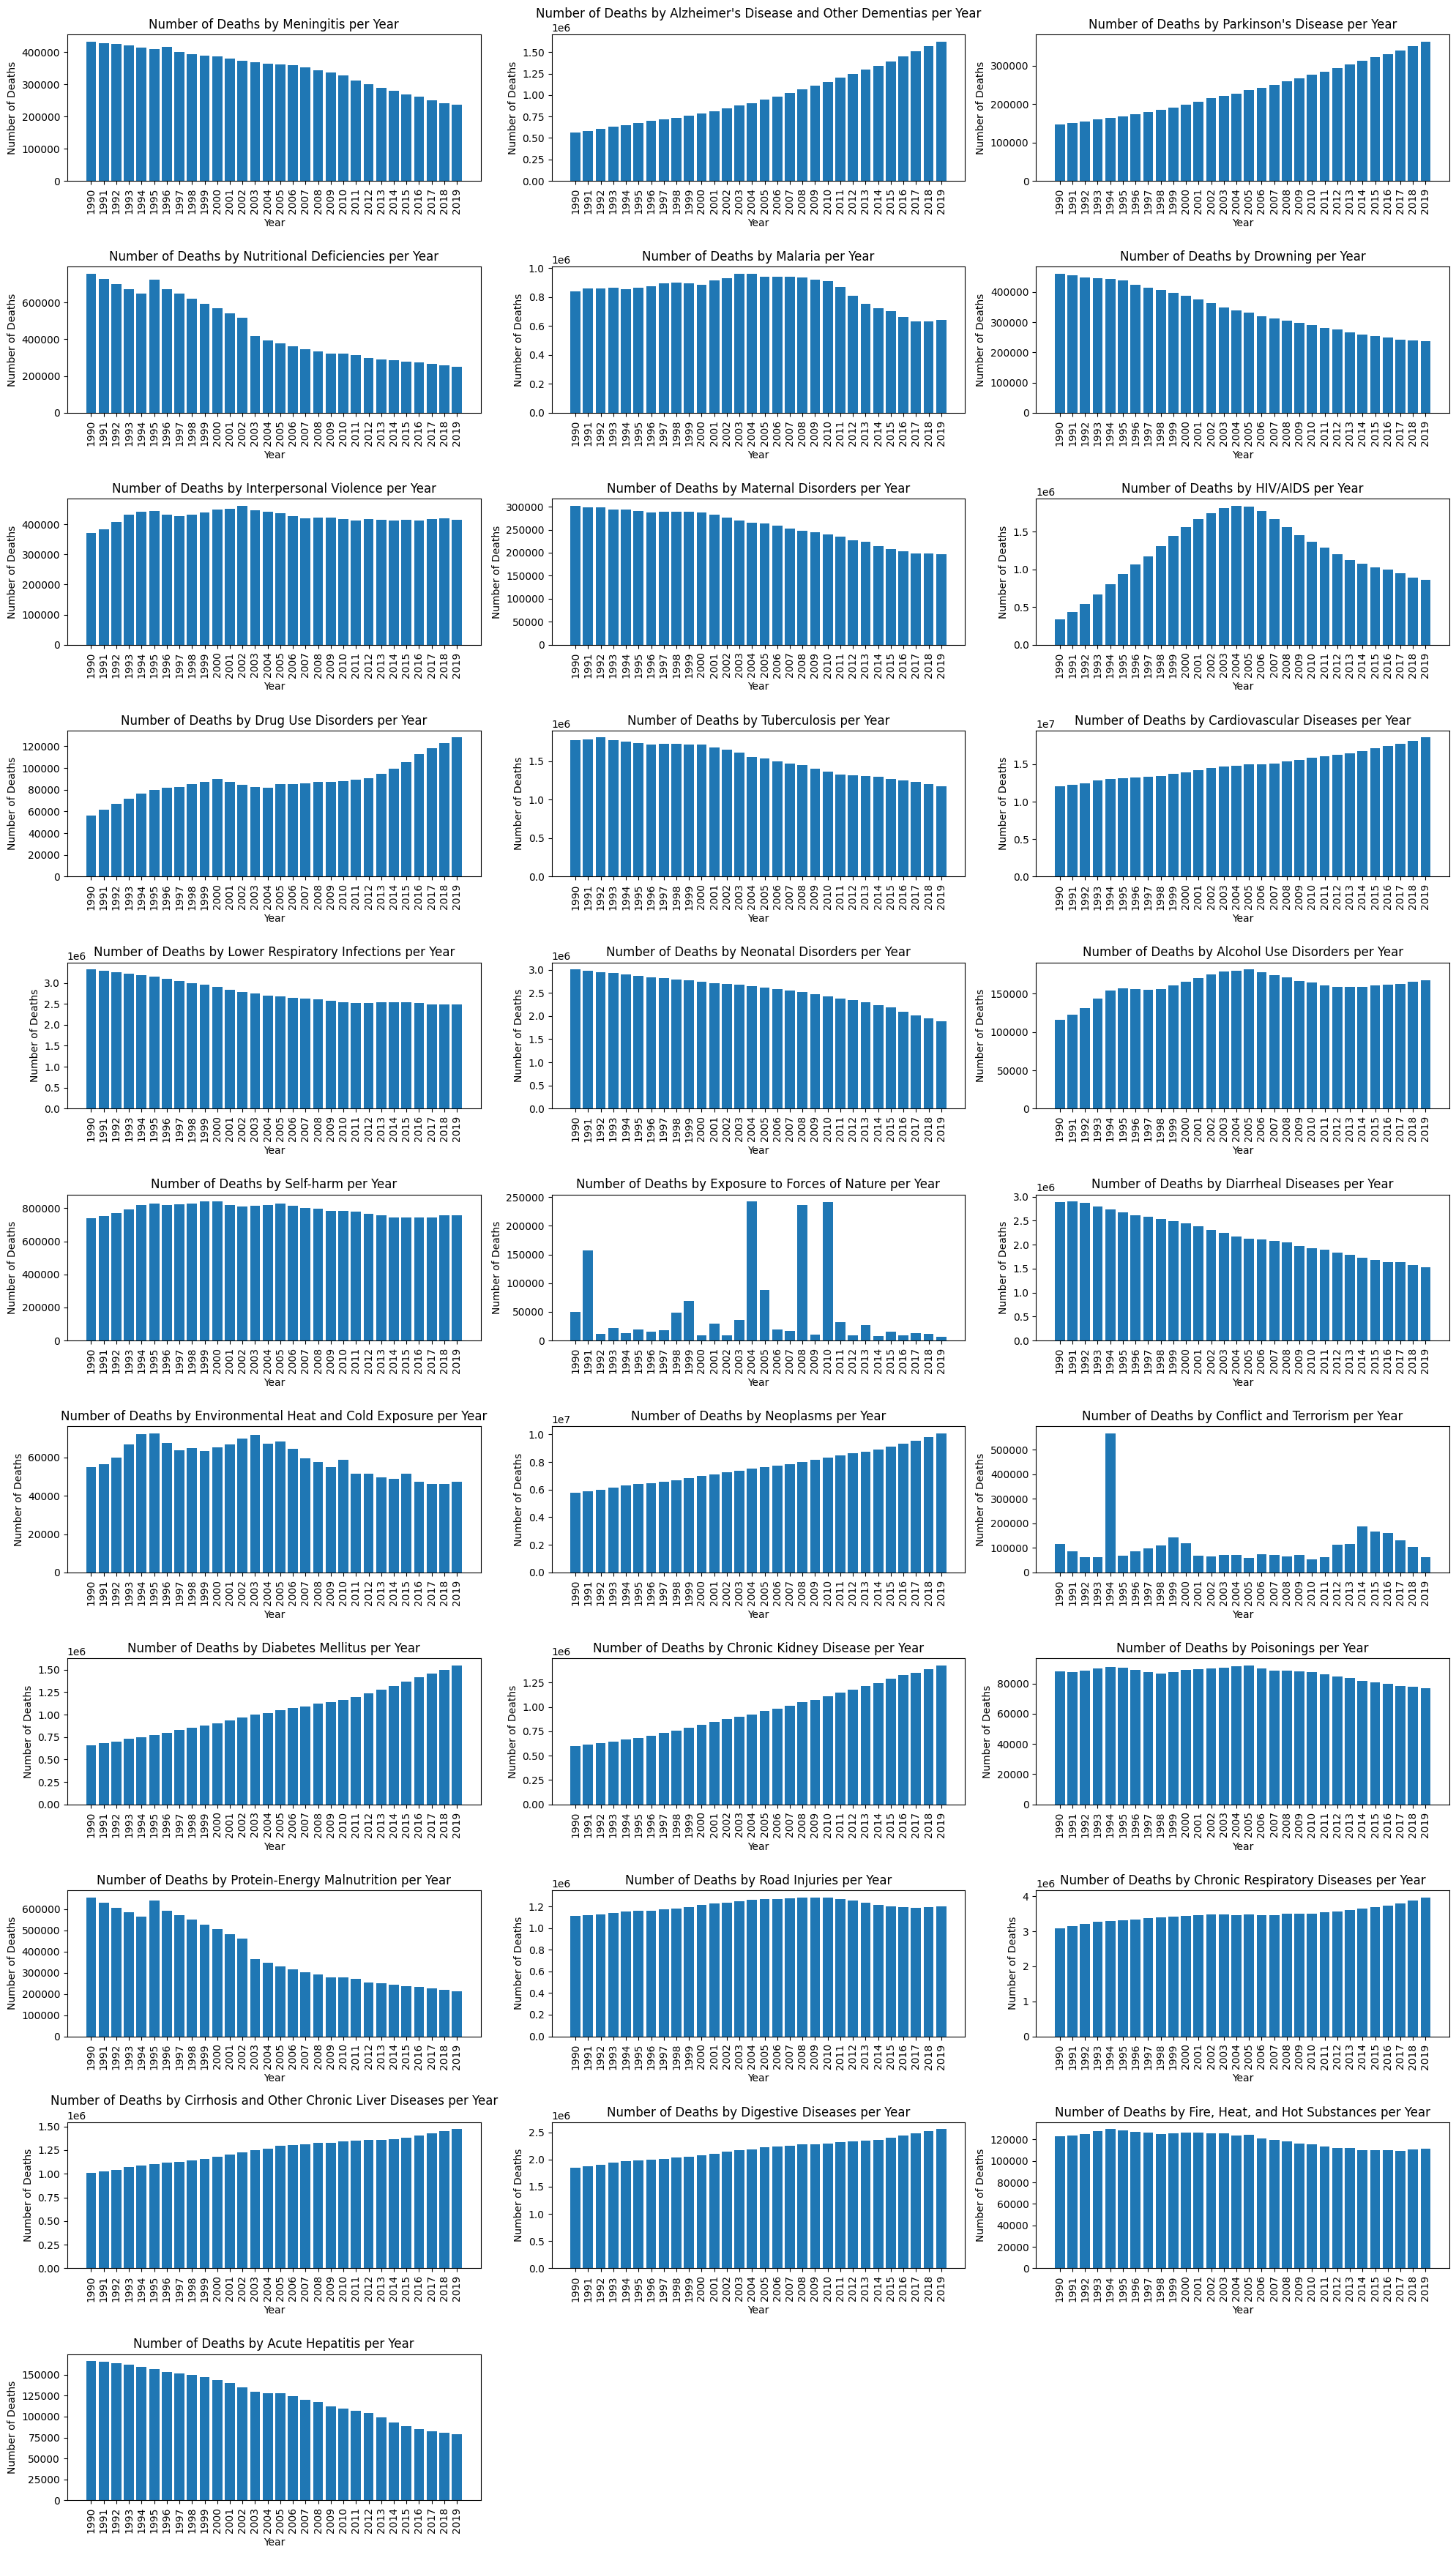

In [9]:
# Plot for number of deaths for each cause per year
cause_cols = data.columns[3:]

deaths_by_year = data.groupby('Year')[cause_cols].sum()

# Set up the subplot grid
fig, ax = plt.subplots(11, 3, figsize=(20, 35))

ax_flat = ax.flatten()
for i, (cause, subplot) in enumerate(zip(cause_cols, ax_flat)):
    subplot.bar(deaths_by_year.index, deaths_by_year[cause])
    subplot.set_xlabel('Year')
    subplot.set_ylabel('Number of Deaths')
    subplot.set_title(f'Number of Deaths by {cause} per Year')
    subplot.set_xticks(deaths_by_year.index)
    subplot.set_xticklabels(deaths_by_year.index, rotation=90)

# Remove any unused subplots
for j in range(i + 1, len(ax_flat)):
    fig.delaxes(ax_flat[j])

plt.tight_layout()
plt.show()

### 2. Top 5 Countries with the Highest Average Number of Cardiovascular Diseases

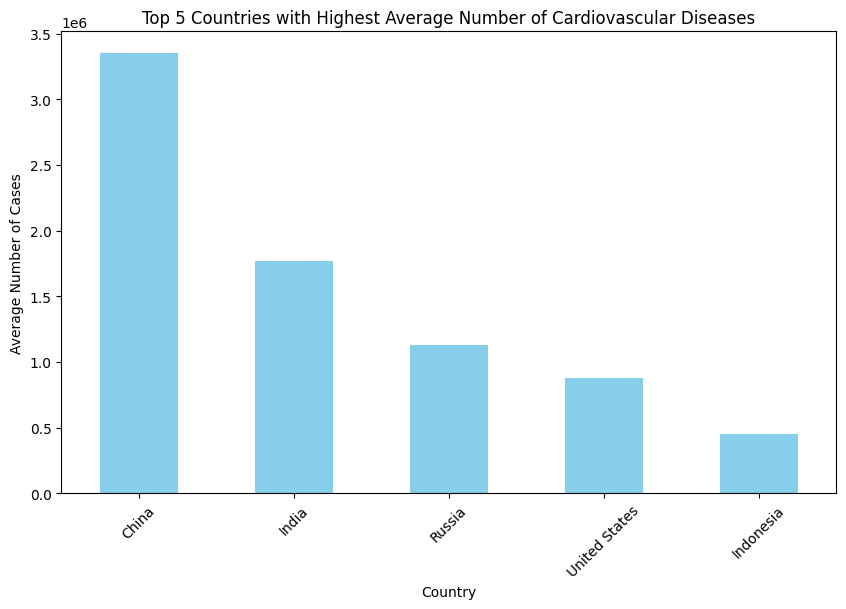

In [10]:
top_countries_cardiovascular = data.groupby('Country/Territory')['Cardiovascular Diseases'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
top_countries_cardiovascular.plot(kind='bar', color='skyblue')
plt.title('Top 5 Countries with Highest Average Number of Cardiovascular Diseases')
plt.xlabel('Country')
plt.ylabel('Average Number of Cases')
plt.xticks(rotation=45)
plt.show()

### 3. Number of road injuries over the years in Afghanistan

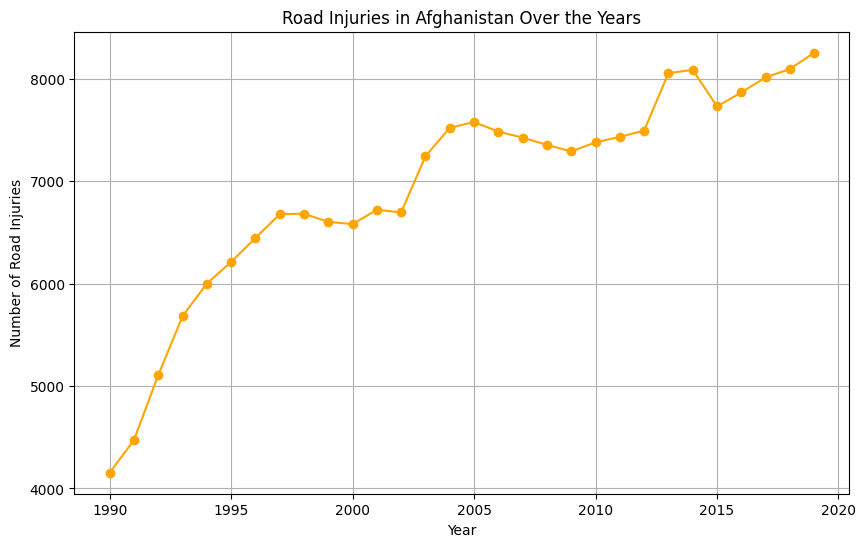

In [11]:
afghanistan_road_injuries = data[data['Country/Territory'] == 'Afghanistan'][['Year', 'Road Injuries']]

plt.figure(figsize=(10, 6))
plt.plot(afghanistan_road_injuries['Year'], afghanistan_road_injuries['Road Injuries'], marker='o', linestyle='-', color='orange')
plt.title('Road Injuries in Afghanistan Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Road Injuries')
plt.grid(True)
plt.show()

### 4. Is there a correlation between self harm and the prevalence of digestive disease?

In [12]:
data_sHarm_Diges = data[["Self-harm", "Digestive Diseases"]]
data_sHarm_Diges.corr()

,Self-harm,Digestive Diseases
Self-harm,1.000000,0.948337
Digestive Diseases,0.948337,1.000000


<Axes: xlabel='Self-harm', ylabel='Digestive Diseases'>

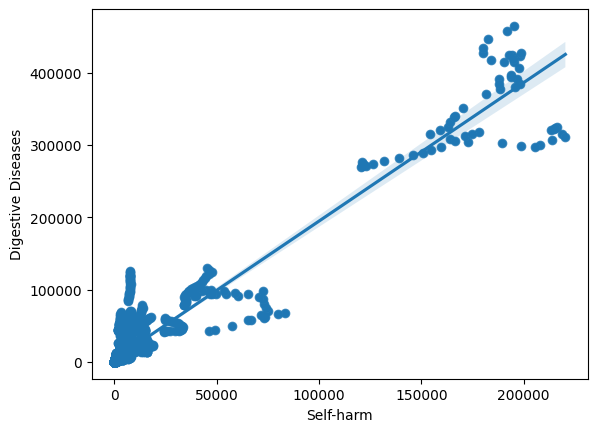

In [13]:
sns.scatterplot(x="Self-harm", y="Digestive Diseases", data=data_sHarm_Diges)
sns.regplot(x="Self-harm", y="Digestive Diseases", data=data_sHarm_Diges)

### Correlation Matrix

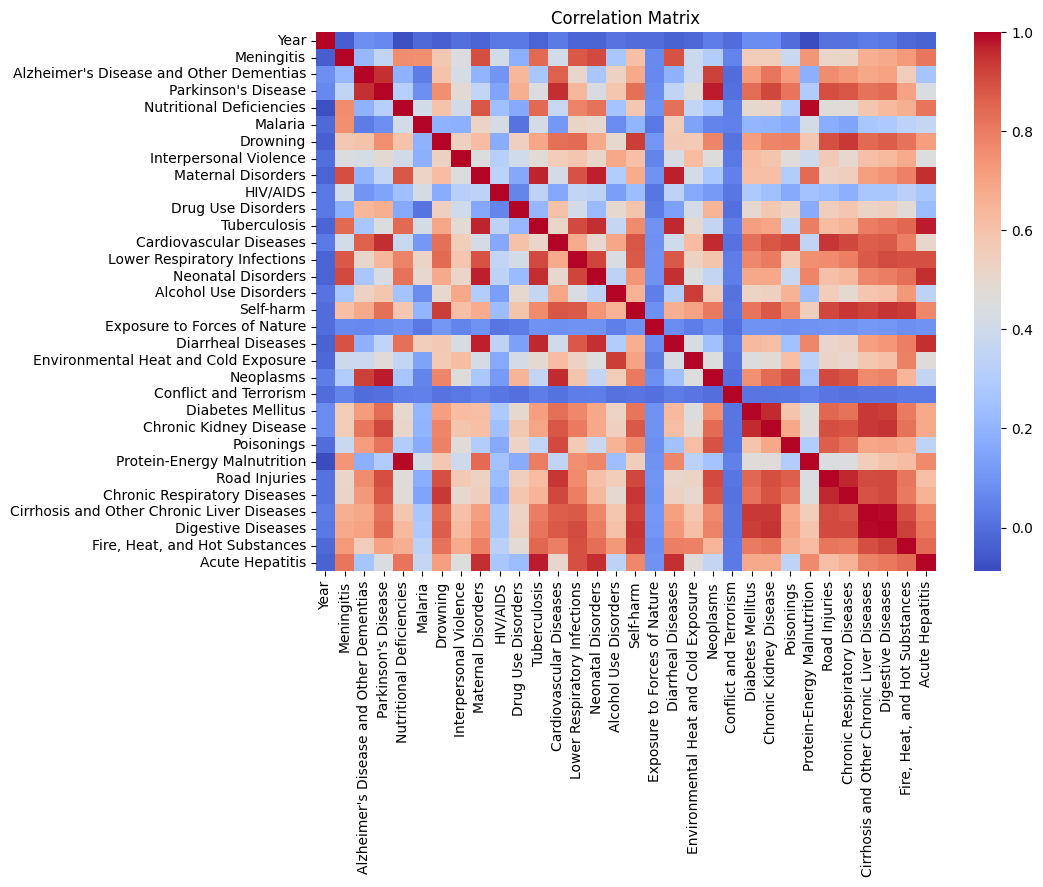

In [14]:
# Plotting a correlation matrix
numerical_data = data.select_dtypes(include=['float64', 'int64'])
cor = numerical_data.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(cor, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Feature Selection

In [15]:
# Target variable: Total deaths (sum of all deaths due to various causes)
data['Total_Deaths'] = data.iloc[:, 3:].sum(axis=1)

# Feature variables: Year and other columns related to death causes
features = ['Year'] + list(data.columns[3:-1])
X = data[features]
y = data['Total_Deaths']

## Data Normalization

In [16]:
# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.67524673,  0.06584744, -0.20572777, ..., -0.15366731,
        -0.12483969,  0.5653966 ],
       [-1.55971247,  0.07469108, -0.20463003, ..., -0.15057799,
        -0.1206112 ,  0.59095994],
       [-1.44417822,  0.11321337, -0.20320296, ..., -0.1448023 ,
        -0.10745591,  0.64662591],
       ...,
       [ 1.44417822, -0.0389272 , -0.224115  , ..., -0.17147792,
         0.03067464, -0.11334592],
       [ 1.55971247, -0.04042612, -0.22334658, ..., -0.17053769,
         0.03208414, -0.11454046],
       [ 1.67524673, -0.04042612, -0.2224135 , ..., -0.16892587,
         0.0344333 , -0.11525719]])

## Data Splitting

In [17]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Data Mining(Random Forest)

## Model Training

In [18]:
# Training the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
# Making predictions
y_pred = model.predict(X_test)

## Model Evaluation

In [20]:
# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_score = model.score(X_test, y_test)

## Results and Predictions

In [21]:
# Creating a DataFrame to tabulate the actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual Values': y_test.values,
    'Predicted Values': y_pred
})

# Displaying the results
results = f"""
Model Evaluation Results:
--------------------------
Mean Squared Error (MSE): {mse}
Root Mean Squared Error (RMSE): {rmse}
R^2 Score: {r2_score}

Actual vs Predicted Values (First 10 samples):
"""

# Printing the evaluation results
print(results)

# Displaying the actual vs predicted values
print(comparison_df.head(10))


Model Evaluation Results:
--------------------------
Mean Squared Error (MSE): 492393425.30526114
Root Mean Squared Error (RMSE): 22189.939731897903
R^2 Score: 0.9991605631879467

Actual vs Predicted Values (First 10 samples):

   Actual Values  Predicted Values
0         110367         111670.86
1          81061          82892.17
2            736            737.54
3         348136         356498.88
4          27255          27674.40
5          25035          25620.84
6           2730           2714.10
7            952            964.17
8         746513         724823.91
9          29070          28986.40


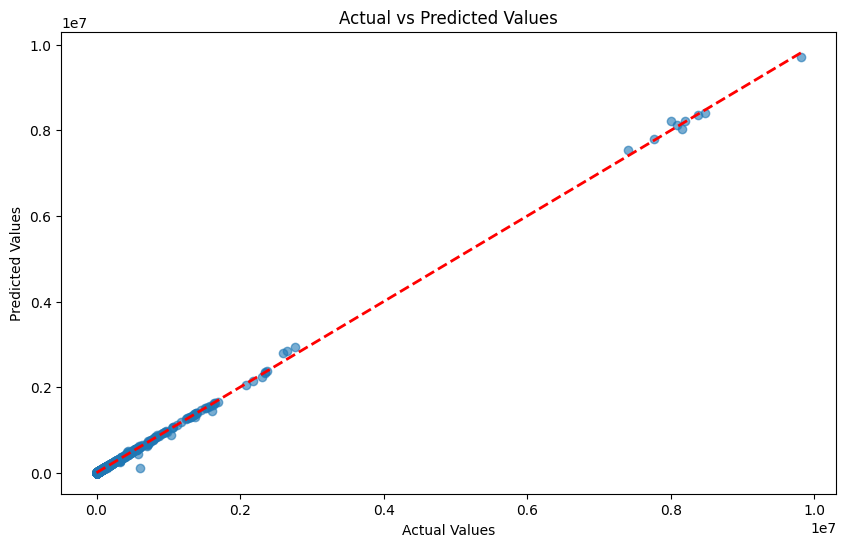

In [22]:
# Scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['Actual Values'], comparison_df['Predicted Values'], alpha=0.6)
plt.plot([comparison_df['Actual Values'].min(), comparison_df['Actual Values'].max()],
         [comparison_df['Actual Values'].min(), comparison_df['Actual Values'].max()],
         color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

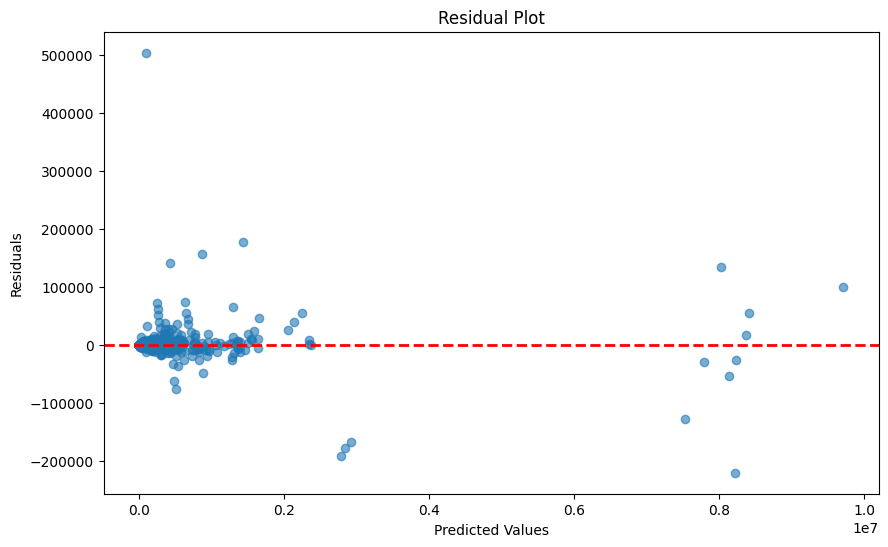

In [23]:
# Calculating residuals
comparison_df['Residuals'] = comparison_df['Actual Values'] - comparison_df['Predicted Values']

# Residual plot
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['Predicted Values'], comparison_df['Residuals'], alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

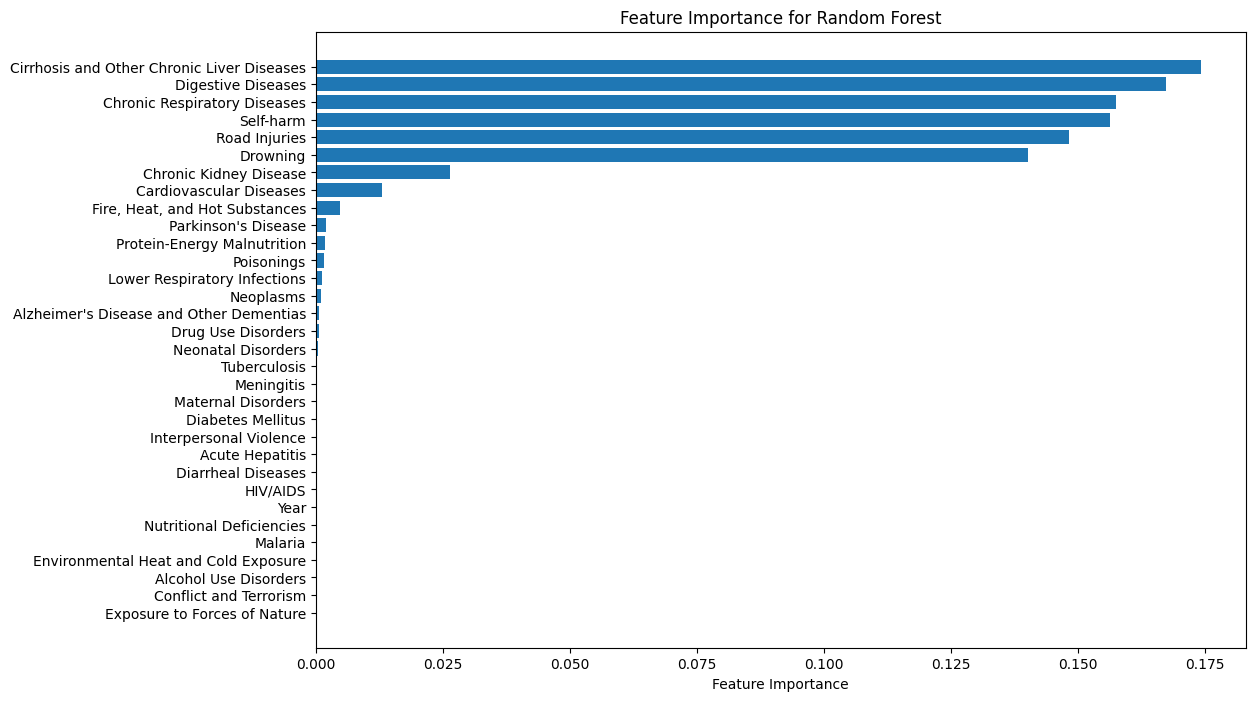

In [24]:
# Feature Importance
importance = model.feature_importances_

# Creating a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sorting the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Random Forest')
plt.gca().invert_yaxis()
plt.show()

#Data Mining (Linear Regression)

##Model Training

In [25]:
# Training the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
# Making predictions
y_pred = model.predict(X_test)

##Model Evaluation

In [27]:
# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_score = model.score(X_test, y_test)

##Results and Predictions

In [28]:
# Creating a DataFrame to tabulate the actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual Values': y_test.values,
    'Predicted Values': y_pred
})

# Displaying the results
results = f"""
Model Evaluation Results:
--------------------------
Mean Squared Error (MSE): {mse}
Root Mean Squared Error (RMSE): {rmse}
R^2 Score: {r2_score}

Actual vs Predicted Values (First 10 samples):
"""

# Printing the evaluation results
print(results)

# Displaying the actual vs predicted values
print(comparison_df.head(10))


Model Evaluation Results:
--------------------------
Mean Squared Error (MSE): 1.2218443343939465e-18
Root Mean Squared Error (RMSE): 1.105370677372051e-09
R^2 Score: 1.0

Actual vs Predicted Values (First 10 samples):

   Actual Values  Predicted Values
0         110367          110367.0
1          81061           81061.0
2            736             736.0
3         348136          348136.0
4          27255           27255.0
5          25035           25035.0
6           2730            2730.0
7            952             952.0
8         746513          746513.0
9          29070           29070.0


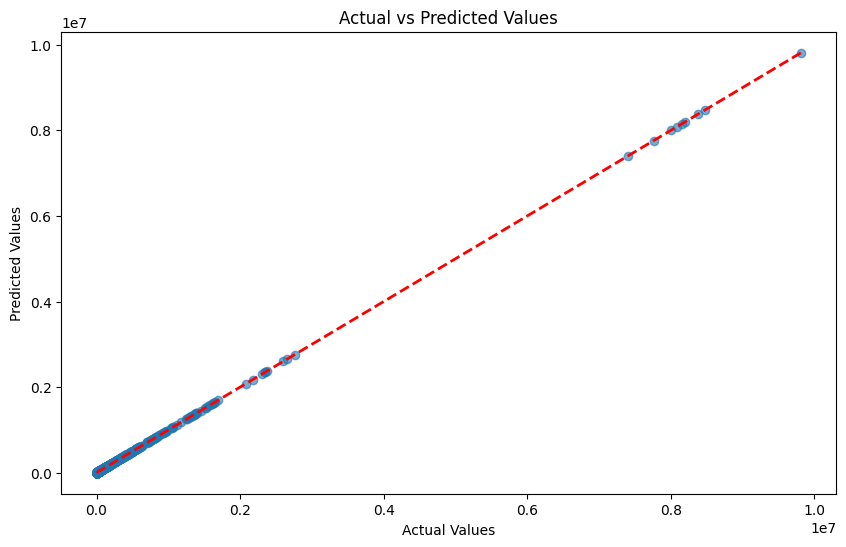

In [29]:
# Scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['Actual Values'], comparison_df['Predicted Values'], alpha=0.6)
plt.plot([comparison_df['Actual Values'].min(), comparison_df['Actual Values'].max()],
         [comparison_df['Actual Values'].min(), comparison_df['Actual Values'].max()],
         color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

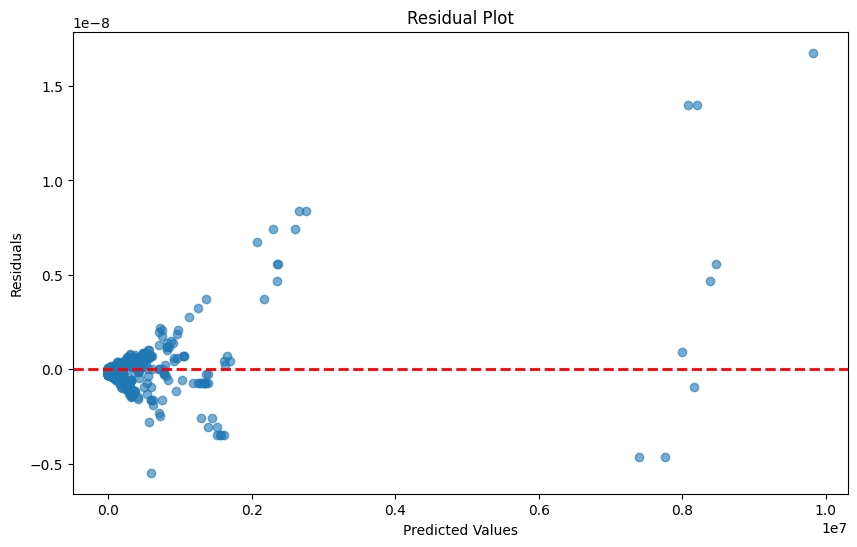

In [30]:
# Calculating residuals
comparison_df['Residuals'] = comparison_df['Actual Values'] - comparison_df['Predicted Values']

# Residual plot
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['Predicted Values'], comparison_df['Residuals'], alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

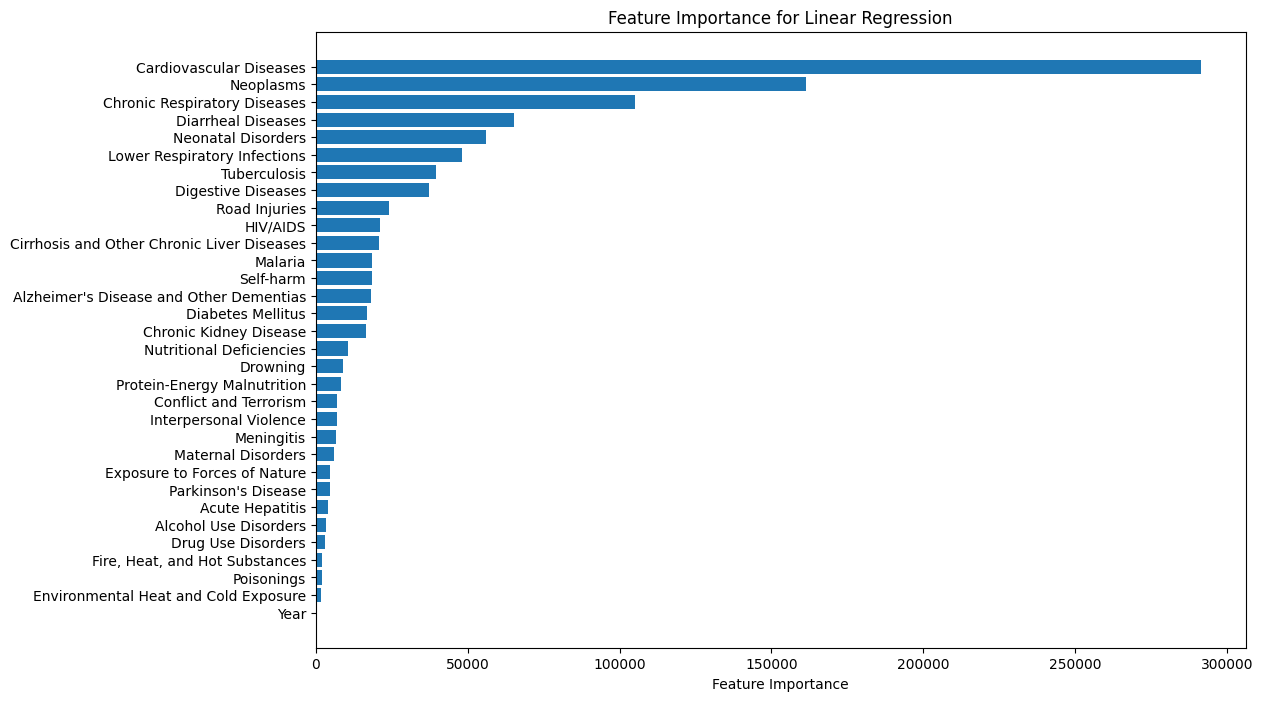

In [31]:
# Extracting feature importance (coefficients)
importance = model.coef_

# Creating a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sorting the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Linear Regression')
plt.gca().invert_yaxis()
plt.show()

#Data Mining (XG Boost)

##Model Training

In [32]:
# Training and fitting the XGBoost model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [33]:
# Making predictions
y_pred = model.predict(X_test)

##Model Evaluation

In [34]:
# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_score = model.score(X_test, y_test)

##Results and Predictions

In [35]:
# Creating a DataFrame to tabulate the actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual Values': y_test.values,
    'Predicted Values': y_pred
})

# Displaying the results
results = f"""
Model Evaluation Results:
--------------------------
Mean Squared Error (MSE): {mse}
Root Mean Squared Error (RMSE): {rmse}
R^2 Score: {r2_score}

Actual vs Predicted Values (First 10 samples):
"""

# Printing the evaluation results
print(results)

# Displaying the actual vs predicted values
print(comparison_df.head(10))


Model Evaluation Results:
--------------------------
Mean Squared Error (MSE): 518870761.63116354
Root Mean Squared Error (RMSE): 22778.73485580715
R^2 Score: 0.9991154243829691

Actual vs Predicted Values (First 10 samples):

   Actual Values  Predicted Values
0         110367     111363.195312
1          81061      81523.914062
2            736        801.006470
3         348136     343571.343750
4          27255      29637.898438
5          25035      24626.861328
6           2730       2869.583008
7            952        890.304932
8         746513     766630.062500
9          29070      28708.265625


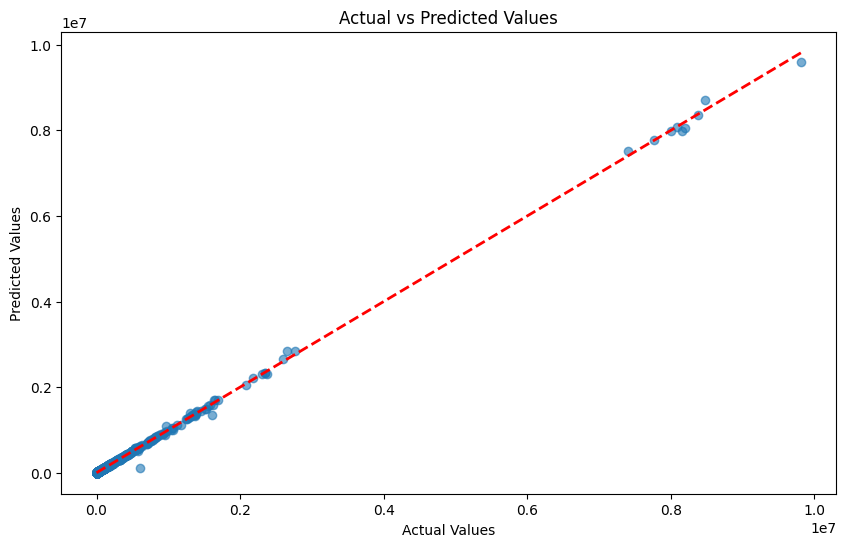

In [36]:
# Scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['Actual Values'], comparison_df['Predicted Values'], alpha=0.6)
plt.plot([comparison_df['Actual Values'].min(), comparison_df['Actual Values'].max()],
         [comparison_df['Actual Values'].min(), comparison_df['Actual Values'].max()],
         color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

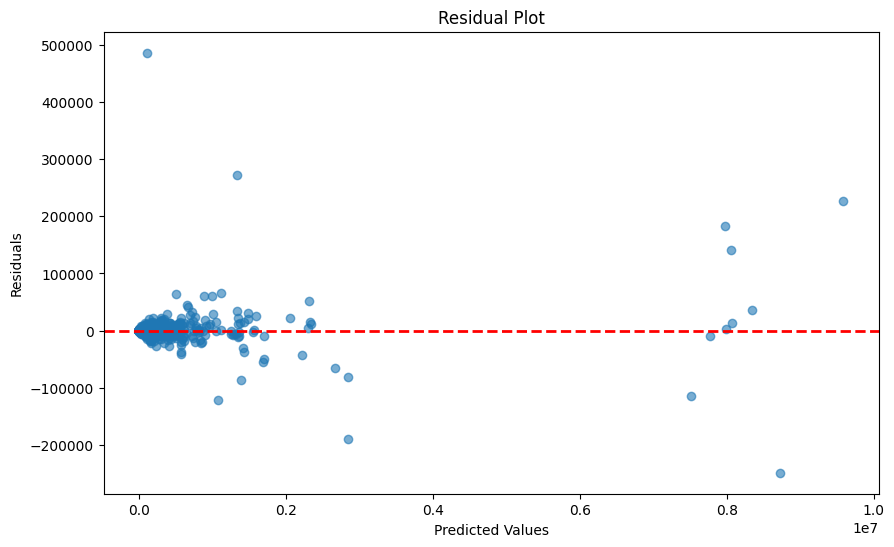

In [37]:
# Calculating residuals
comparison_df['Residuals'] = comparison_df['Actual Values'] - comparison_df['Predicted Values']

# Residual plot
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['Predicted Values'], comparison_df['Residuals'], alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

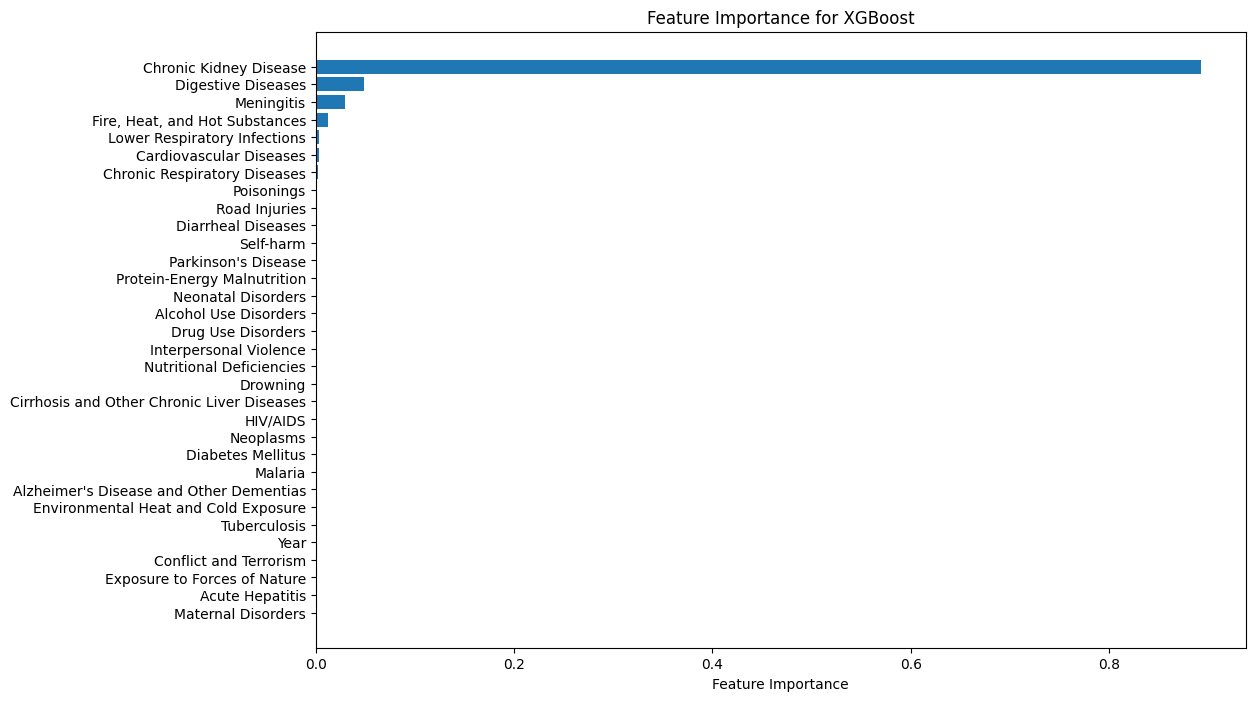

In [38]:
# Feature Importance
importance = model.feature_importances_

# Creating a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sorting the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance for XGBoost')
plt.gca().invert_yaxis()
plt.show()